<a href="https://colab.research.google.com/github/iqlore-collab/housing-market-intelligence-supervised-unsupervised-ml-public/blob/main/housing_market_intelligence_iteration5_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Housing Market Intelligence

## One dataset. Two ML perspectives.

This version uses a single dataset: `housing_iteration_5_classification.csv`.

The target column is `Expensive`.

I use the same dataset in two different ways:

1. **Unsupervised learning** — I hide the target and ask whether the market forms natural housing archetypes.
2. **Supervised learning** — I bring the target back and test whether those expensive homes can be predicted.

This feels more honest than using two separate CSV files: the unsupervised and supervised parts now investigate the same market from two angles.

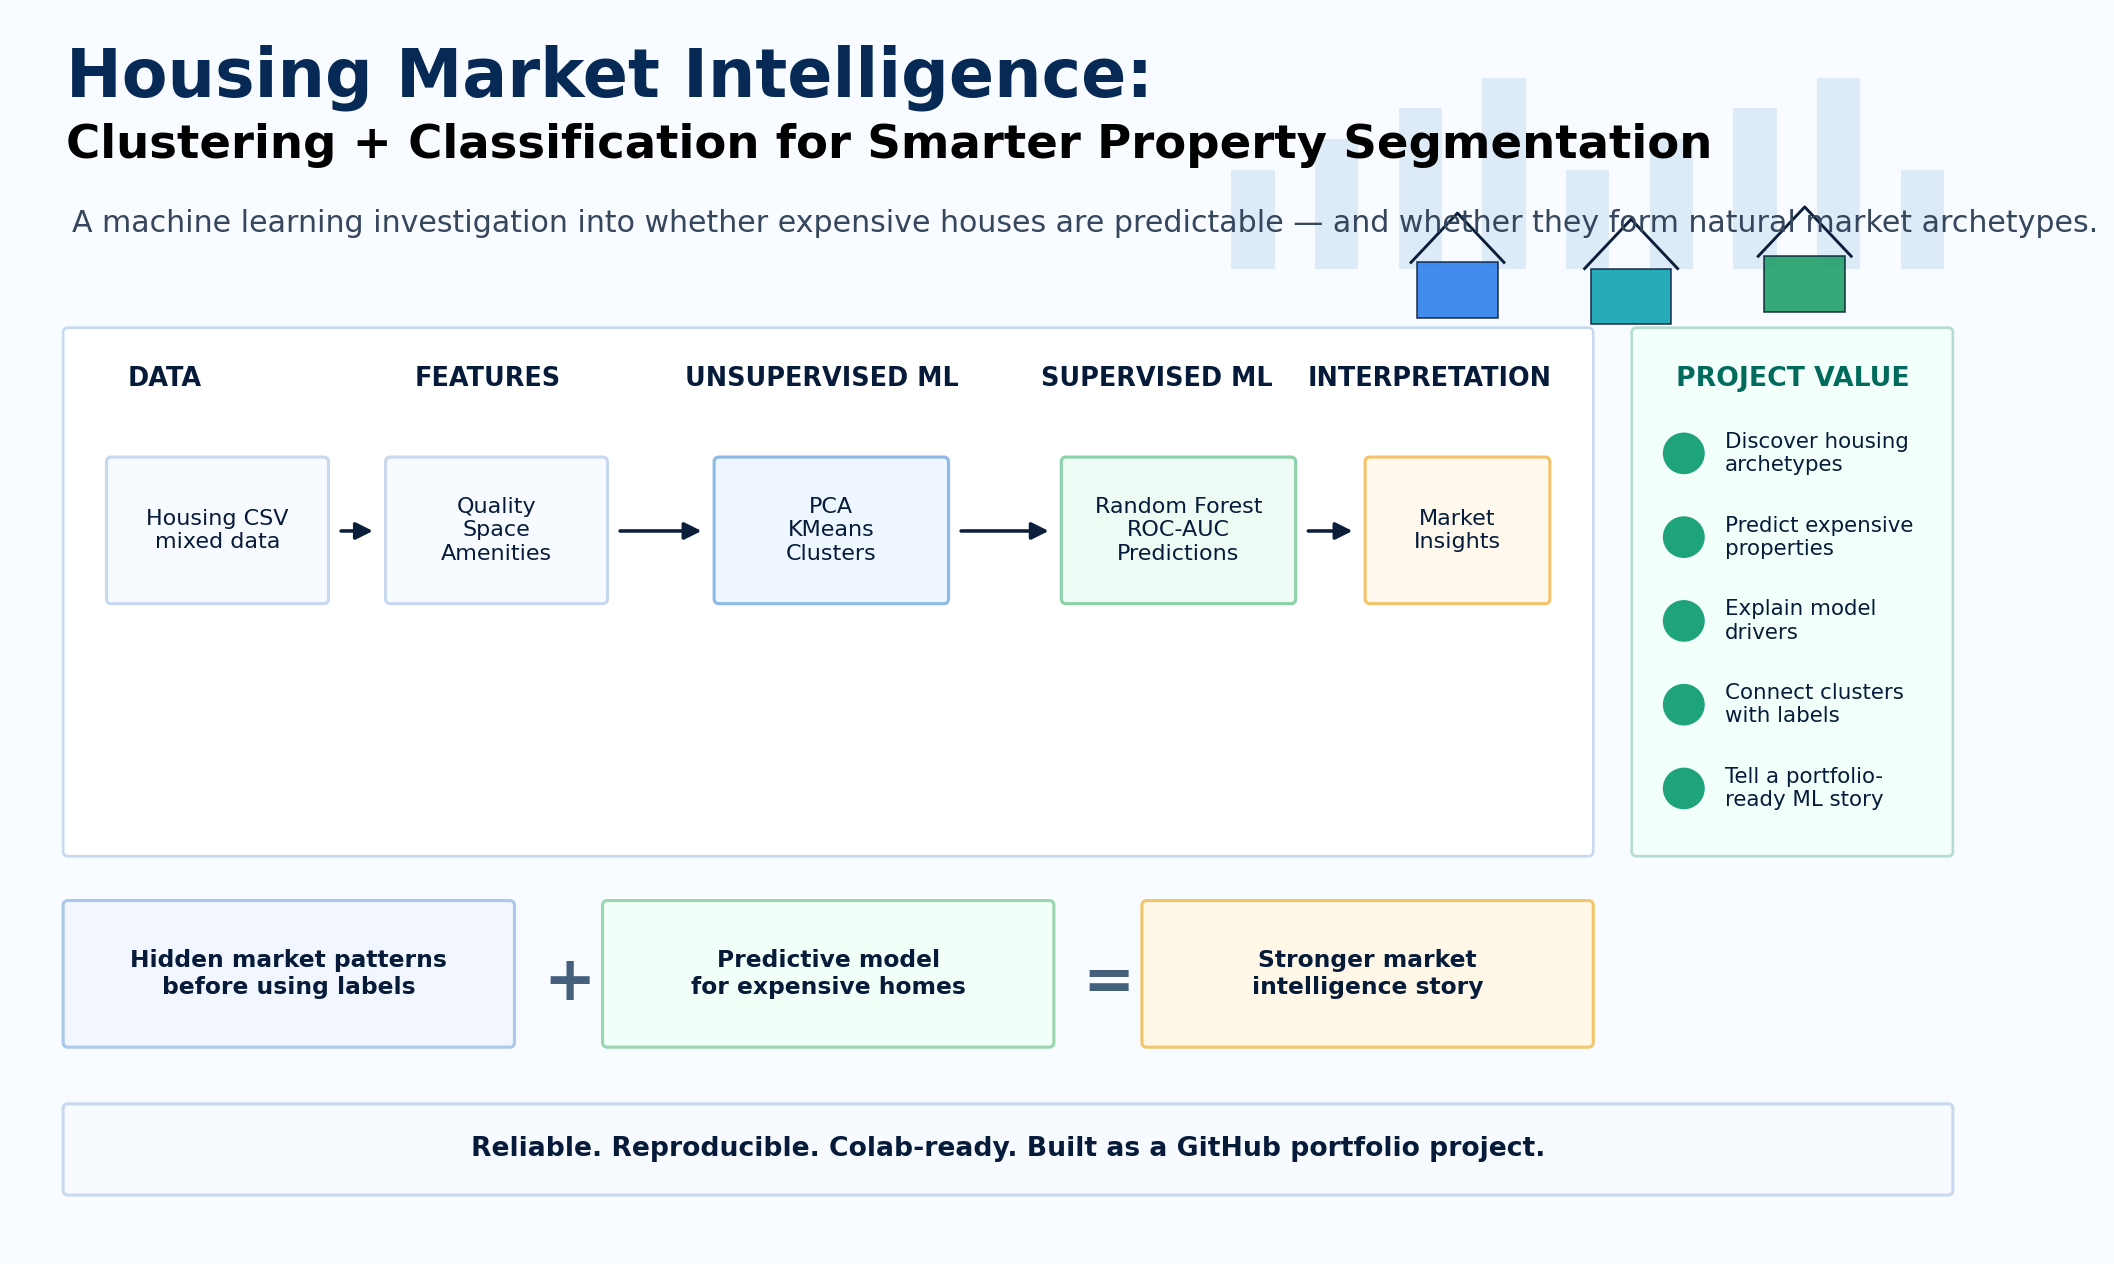

In [22]:
from IPython.display import Image, display

display(Image("/content/drive/MyDrive/Colab Notebooks/images/ml_pipeline_infographic.png"))

## 1. Setup

This notebook is designed for Google Colab, but it also works locally.

Expected file:

- `housing_iteration_5_classification.csv`

Recommended structure:

```text
housing-market-intelligence/
├── data/
│   └── housing_iteration_5_classification.csv
├── images/
└── notebooks/
```

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print("Google Drive mount skipped. Running locally or outside Colab.")

Mounted at /content/drive


In [ ]:
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

RANDOM_STATE = 42
TARGET_COL = "Expensive"
DATA_FILE = "housing_iteration_5_classification.csv"

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [ ]:
def find_file(filename):
    search_roots = [
        Path.cwd(),
        Path("/content"),
        Path("/content/drive/MyDrive"),
        Path("../data"),
        Path("./data"),
        Path("/mnt/data")
    ]

    for root in search_roots:
        if not root.exists():
            continue

        direct = root / filename
        if direct.exists():
            return str(direct)

        if str(root) in ["/content", "/content/drive/MyDrive"]:
            matches = list(root.rglob(filename))
            if matches:
                return str(matches[0])

    raise FileNotFoundError(
        f"Could not find {filename}. Put it in data/, current folder, or Google Drive."
    )

data_path = find_file(DATA_FILE)
df_raw = pd.read_csv(data_path)

print("Dataset path:", data_path)
print("Dataset shape:", df_raw.shape)

Dataset path: /content/drive/MyDrive/Colab Notebooks/housing_iteration_5_classification.csv
Dataset shape: (1460, 81)


## 2. First inspection

Before modeling, I check the dataset shape, target distribution and missing values.

In [ ]:
display(df_raw.head())

print("Number of columns:", len(df_raw.columns))
print("Target present:", TARGET_COL in df_raw.columns)

if TARGET_COL not in df_raw.columns:
    raise ValueError(f"Expected target column {TARGET_COL} was not found.")

print("Numeric columns:", df_raw.select_dtypes(include=["number", "bool"]).shape[1])
print("Categorical columns:", df_raw.select_dtypes(include=["object", "category"]).shape[1])

,LotArea,LotFrontage,TotalBsmtSF,BedroomAbvGr,Fireplaces,PoolArea,GarageCars,WoodDeckSF,ScreenPorch,Expensive,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,8450,65.0,856,3,0,0,2,0,0,0,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,9600,80.0,1262,3,1,0,2,298,0,0,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,11250,68.0,920,3,1,0,2,0,0,0,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,9550,60.0,756,3,1,0,3,0,0,0,...,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,14260,84.0,1145,4,1,0,3,192,0,0,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal


Number of columns: 81
Target present: True
Numeric columns: 38
Categorical columns: 43


,share
Expensive,
0,0.85137
1,0.14863


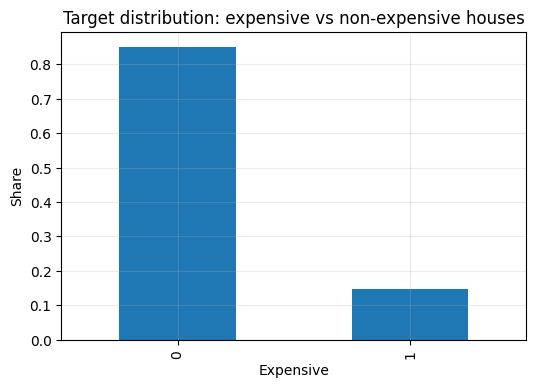

In [ ]:
target_rate = df_raw[TARGET_COL].value_counts(normalize=True).sort_index()

display(target_rate.to_frame("share"))

ax = target_rate.plot(kind="bar", figsize=(6, 4))
ax.set_title("Target distribution: expensive vs non-expensive houses")
ax.set_xlabel("Expensive")
ax.set_ylabel("Share")
plt.show()

In [ ]:
missing = (
    df_raw.isna().mean()
    .sort_values(ascending=False)
    .head(20)
    .to_frame("missing_share")
)

display(missing)

,missing_share
PoolQC,0.995205
MiscFeature,0.963014
Alley,0.937671
Fence,0.807534
MasVnrType,0.597260
FireplaceQu,0.472603
LotFrontage,0.177397
GarageYrBlt,0.055479
GarageType,0.055479
GarageFinish,0.055479


### About the target label

The `Expensive` column is a simplified high-value segment label.

I treat it as useful but not perfect. This is why I first explore the housing market without the label, and only later use it for prediction.

## 3. Feature engineering

This dataset is closer to the original Ames-style housing structure, so I can create more meaningful features than in the previous engineered CSVs.

I add signals related to:

- total living space,
- total bathrooms,
- property age,
- remodeling age,
- outdoor space,
- garage strength,
- quality-condition gap,
- amenity count,
- premium/luxury signals.

In [ ]:
def safe_series(df, column, default=0):
    if column in df.columns:
        return df[column]
    return pd.Series(default, index=df.index)

def add_market_features(df):
    df = df.copy()

    df["TotalSF"] = (
        safe_series(df, "TotalBsmtSF")
        + safe_series(df, "1stFlrSF")
        + safe_series(df, "2ndFlrSF")
    )

    df["TotalBathrooms"] = (
        safe_series(df, "FullBath")
        + 0.5 * safe_series(df, "HalfBath")
        + safe_series(df, "BsmtFullBath")
        + 0.5 * safe_series(df, "BsmtHalfBath")
    )

    df["HouseAgeAtSale"] = safe_series(df, "YrSold") - safe_series(df, "YearBuilt")
    df["RemodelAgeAtSale"] = safe_series(df, "YrSold") - safe_series(df, "YearRemodAdd")
    df["GarageAgeAtSale"] = safe_series(df, "YrSold") - safe_series(df, "GarageYrBlt")

    df["OutdoorSpace"] = (
        safe_series(df, "WoodDeckSF")
        + safe_series(df, "OpenPorchSF")
        + safe_series(df, "EnclosedPorch")
        + safe_series(df, "3SsnPorch")
        + safe_series(df, "ScreenPorch")
        + safe_series(df, "PoolArea")
    )

    df["HasGarage"] = (safe_series(df, "GarageCars") > 0).astype(int)
    df["HasFireplace"] = (safe_series(df, "Fireplaces") > 0).astype(int)
    df["HasPool"] = (safe_series(df, "PoolArea") > 0).astype(int)
    df["HasDeckOrPorch"] = (df["OutdoorSpace"] > 0).astype(int)
    df["HasBasement"] = (safe_series(df, "TotalBsmtSF") > 0).astype(int)

    df["AmenityCount"] = (
        df["HasGarage"]
        + df["HasFireplace"]
        + df["HasPool"]
        + df["HasDeckOrPorch"]
        + df["HasBasement"]
    )

    df["QualityConditionGap"] = safe_series(df, "OverallQual") - safe_series(df, "OverallCond")
    df["GarageIntensity"] = safe_series(df, "GarageArea") / safe_series(df, "GarageCars").replace(0, np.nan)
    df["LotAreaPerRoom"] = safe_series(df, "LotArea") / safe_series(df, "TotRmsAbvGrd").replace(0, np.nan)
    df["SFPerBedroom"] = safe_series(df, "GrLivArea") / safe_series(df, "BedroomAbvGr").replace(0, np.nan)

    df["PremiumSignal"] = (
        (safe_series(df, "OverallQual") >= 8).astype(int)
        + (safe_series(df, "GrLivArea") >= safe_series(df, "GrLivArea").quantile(0.75)).astype(int)
        + (safe_series(df, "GarageCars") >= 3).astype(int)
        + (safe_series(df, "Fireplaces") > 0).astype(int)
        + (safe_series(df, "TotalBathrooms") >= 3).astype(int)
    )

    return df.replace([np.inf, -np.inf], np.nan)

df = add_market_features(df_raw)
print("Shape after feature engineering:", df.shape)

Shape after feature engineering: (1460, 98)


## 4. Mixed-type preprocessing

The dataset contains numeric, ordinal and nominal columns.

For quality-related categories I use ordinal encoding. For nominal categories such as neighborhood or exterior type I use one-hot encoding.

In [ ]:
QUALITY_ORDER = ["Missing", "Po", "Fa", "TA", "Gd", "Ex"]
EXPOSURE_ORDER = ["Missing", "No", "Mn", "Av", "Gd"]
FINISH_ORDER = ["Missing", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"]
GARAGE_FINISH_ORDER = ["Missing", "Unf", "RFn", "Fin"]
FUNCTIONAL_ORDER = ["Missing", "Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"]
PAVED_DRIVE_ORDER = ["Missing", "N", "P", "Y"]

ORDINAL_MAP = {
    "ExterQual": QUALITY_ORDER,
    "ExterCond": QUALITY_ORDER,
    "BsmtQual": QUALITY_ORDER,
    "BsmtCond": QUALITY_ORDER,
    "HeatingQC": QUALITY_ORDER,
    "KitchenQual": QUALITY_ORDER,
    "FireplaceQu": QUALITY_ORDER,
    "GarageQual": QUALITY_ORDER,
    "GarageCond": QUALITY_ORDER,
    "PoolQC": QUALITY_ORDER,
    "BsmtExposure": EXPOSURE_ORDER,
    "BsmtFinType1": FINISH_ORDER,
    "BsmtFinType2": FINISH_ORDER,
    "GarageFinish": GARAGE_FINISH_ORDER,
    "Functional": FUNCTIONAL_ORDER,
    "PavedDrive": PAVED_DRIVE_ORDER,
}

def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def build_preprocessor(df, target=None):
    X = df.drop(columns=[target], errors="ignore").copy()
    X = X.drop(columns=["Id"], errors="ignore")

    numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

    ordinal_features = [c for c in ORDINAL_MAP if c in categorical_features]
    nominal_features = [c for c in categorical_features if c not in ordinal_features]

    transformers = []

    if numeric_features:
        numeric_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
        transformers.append(("num", numeric_pipe, numeric_features))

    if ordinal_features:
        ordinal_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("encoder", OrdinalEncoder(
                categories=[ORDINAL_MAP[c] for c in ordinal_features],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ))
        ])
        transformers.append(("ord", ordinal_pipe, ordinal_features))

    if nominal_features:
        nominal_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("encoder", make_one_hot_encoder())
        ])
        transformers.append(("nom", nominal_pipe, nominal_features))

    return ColumnTransformer(transformers=transformers, remainder="drop"), numeric_features, ordinal_features, nominal_features

preprocessor, numeric_features, ordinal_features, nominal_features = build_preprocessor(df, target=TARGET_COL)

print("Numeric features:", len(numeric_features))
print("Ordinal features:", len(ordinal_features))
print("Nominal features:", len(nominal_features))

Numeric features: 53
Ordinal features: 16
Nominal features: 27


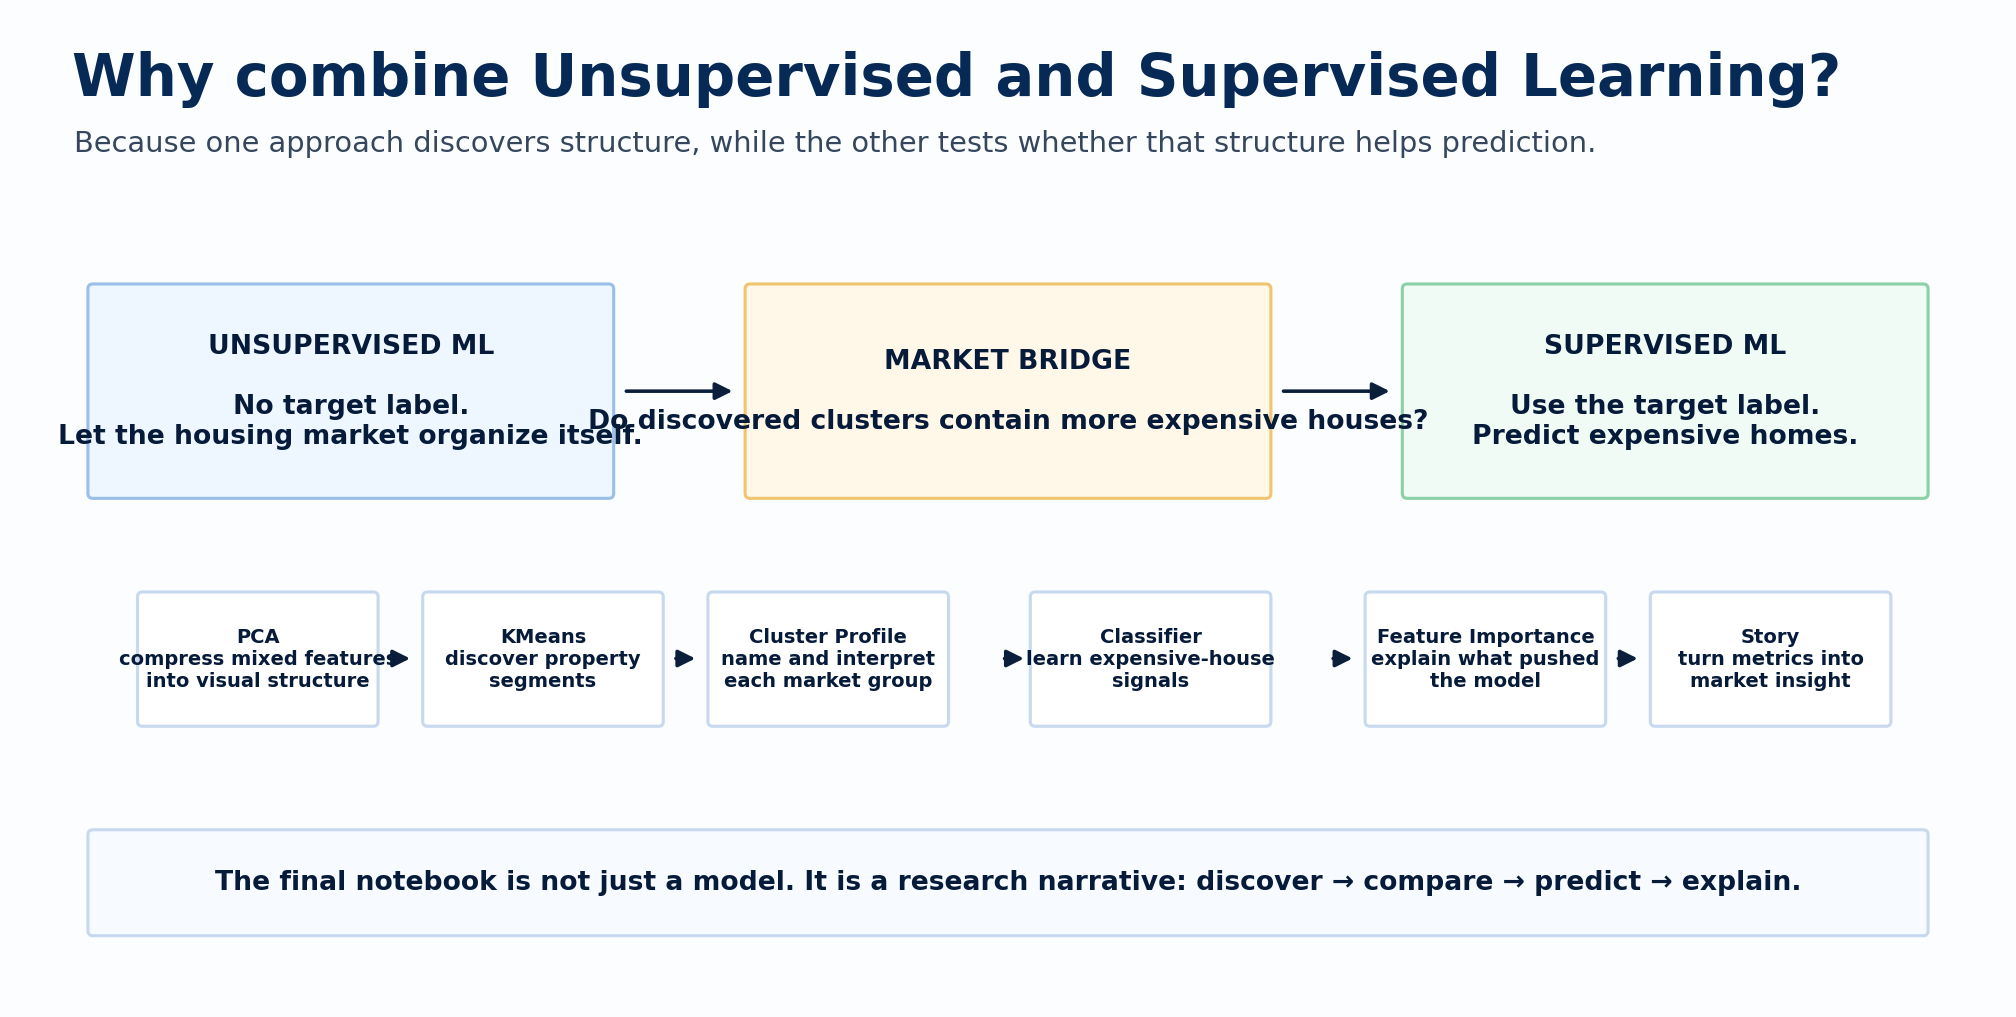

In [24]:
from IPython.display import Image, display

display(Image("/content/drive/MyDrive/Colab Notebooks/images/supervised_unsupervised_bridge.png"))

## 5. Unsupervised learning

I hide the `Expensive` label and let the housing market segment itself.

To keep the workflow stable in Colab, clustering is performed on PCA components rather than directly on the full one-hot encoded matrix.

In [ ]:
X_unsup_df = df.drop(columns=[TARGET_COL])
X_unsup = preprocessor.fit_transform(X_unsup_df)

if hasattr(X_unsup, "toarray"):
    X_unsup = X_unsup.toarray()

n_pca_components = min(12, X_unsup.shape[1], X_unsup.shape[0] - 1)
pca_model = PCA(n_components=n_pca_components, random_state=RANDOM_STATE)
X_cluster = pca_model.fit_transform(X_unsup)
X_pca = X_cluster[:, :2]

print("Preprocessed matrix:", X_unsup.shape)
print("PCA components used for clustering:", n_pca_components)
print("First two components explained variance:", np.round(pca_model.explained_variance_ratio_[:2], 4))
print("Total explained variance in clustering space:", round(float(pca_model.explained_variance_ratio_.sum()), 4))

Preprocessed matrix: (1460, 253)
PCA components used for clustering: 12
First two components explained variance: [0.2144 0.0812]
Total explained variance in clustering space: 0.6246


### PCA note

The PCA scatterplot is a map, not proof of perfect separation.

I use more than two PCA components for clustering, and only the first two for visualization.

,k,silhouette
0,2,0.239095
1,3,0.145165
2,4,0.159994
3,5,0.163182
4,6,0.148492
5,7,0.181185
6,8,0.192918


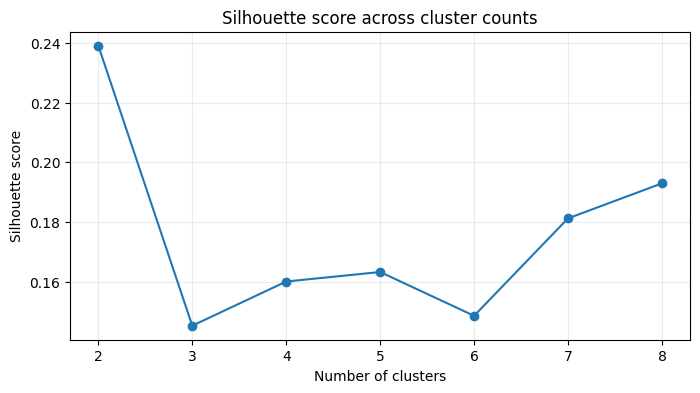

Best k by silhouette: 2
Selected k for market archetypes: 4


In [ ]:
silhouette_results = []

for k in range(2, 9):
    try:
        model = MiniBatchKMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=5,
            batch_size=256,
            max_iter=120
        )
        labels = model.fit_predict(X_cluster)
        score = silhouette_score(
            X_cluster,
            labels,
            sample_size=min(600, len(labels)),
            random_state=RANDOM_STATE
        )
    except Exception as error:
        print(f"k={k} failed: {error}")
        score = np.nan

    silhouette_results.append({"k": k, "silhouette": score})

silhouette_df = pd.DataFrame(silhouette_results)
display(silhouette_df)

plt.figure(figsize=(8, 4))
plt.plot(silhouette_df["k"], silhouette_df["silhouette"], marker="o")
plt.title("Silhouette score across cluster counts")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.show()

valid_scores = silhouette_df.dropna()
best_k_by_score = int(valid_scores.sort_values("silhouette", ascending=False).iloc[0]["k"]) if len(valid_scores) else 4

preferred_k = 4
best_k = preferred_k if preferred_k in silhouette_df["k"].values else best_k_by_score

print("Best k by silhouette:", best_k_by_score)
print("Selected k for market archetypes:", best_k)

### Why I use interpretable `k`

The highest silhouette score is not always the best storytelling model.

If the best score creates only two clusters, the analysis often becomes simply “budget vs premium”. For a market intelligence project I prefer a small set of readable archetypes, so I use four clusters when possible.

Using best_k: 4


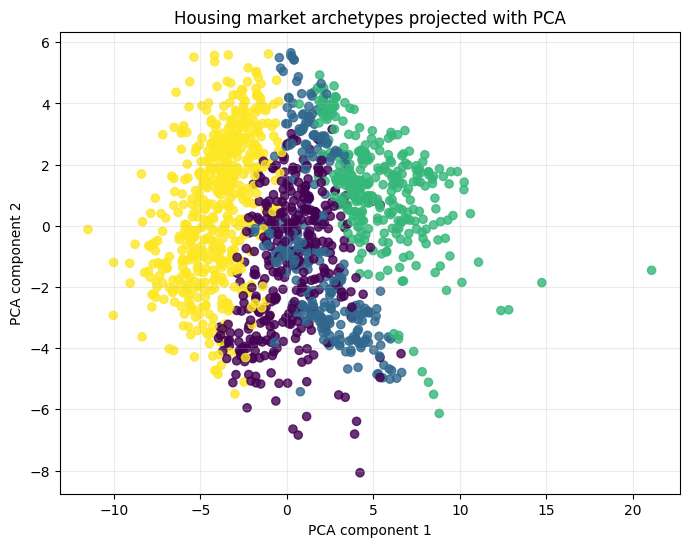

,n_houses
Cluster,
0,349
1,285
2,296
3,530


In [ ]:
if "best_k" not in globals():
    best_k = 4
    print("best_k was missing, using fallback:", best_k)
else:
    print("Using best_k:", best_k)

kmeans = MiniBatchKMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=10,
    batch_size=256,
    max_iter=150
)

cluster_labels = kmeans.fit_predict(X_cluster)

df_segments = df.copy()
df_segments["Cluster"] = cluster_labels

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, s=35, alpha=0.8)
plt.title("Housing market archetypes projected with PCA")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.show()

display(df_segments["Cluster"].value_counts().sort_index().to_frame("n_houses"))

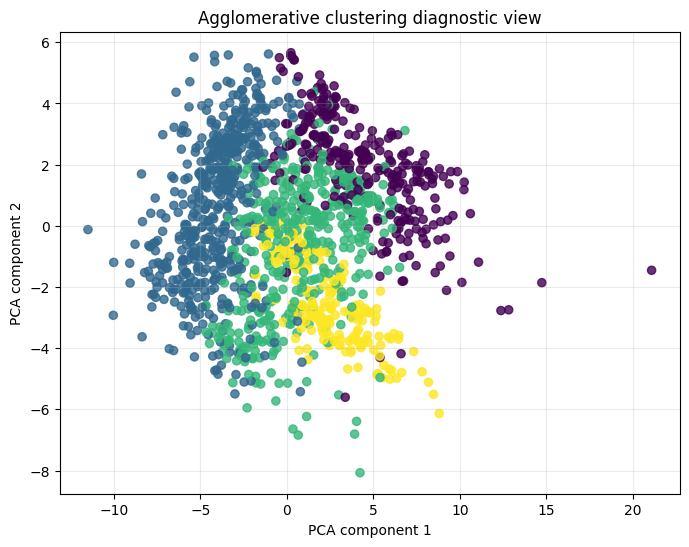

In [ ]:
agg_labels = AgglomerativeClustering(n_clusters=best_k).fit_predict(X_cluster)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, s=35, alpha=0.8)
plt.title("Agglomerative clustering diagnostic view")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.show()

,eps,n_clusters,noise_share
0,1.5,12,0.852055
1,2.0,17,0.662329
2,2.5,8,0.395890
3,3.0,6,0.215068
4,3.5,5,0.117808


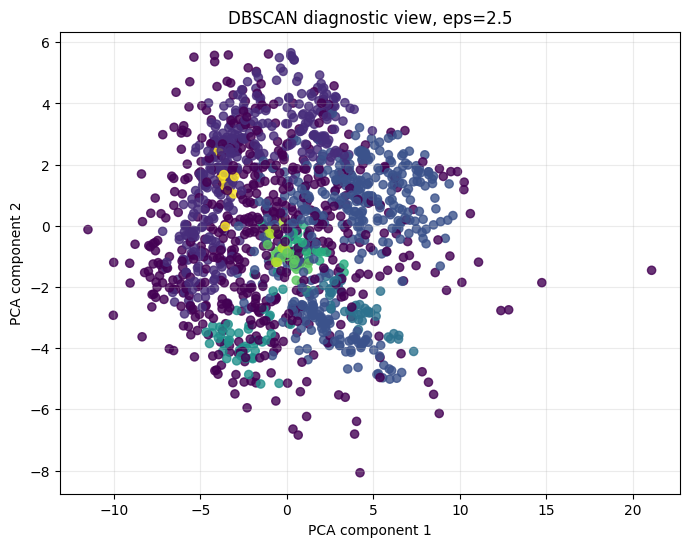

In [ ]:
dbscan_results = []

for eps in [1.5, 2.0, 2.5, 3.0, 3.5]:
    model = DBSCAN(eps=eps, min_samples=8)
    labels = model.fit_predict(X_cluster)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_share = np.mean(labels == -1)
    dbscan_results.append({"eps": eps, "n_clusters": n_clusters, "noise_share": noise_share})

dbscan_results_df = pd.DataFrame(dbscan_results)
display(dbscan_results_df)

dbscan_eps = 2.5
dbscan_labels = DBSCAN(eps=dbscan_eps, min_samples=8).fit_predict(X_cluster)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, s=35, alpha=0.8)
plt.title(f"DBSCAN diagnostic view, eps={dbscan_eps}")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.show()

### DBSCAN note

DBSCAN is diagnostic here. Mixed tabular housing data does not always form density-separated regions, so KMeans remains the main segmentation model.

## 6. Market archetype interpretation

Cluster IDs alone are not useful. I profile each cluster using business-friendly housing signals and then assign readable archetype names.

In [ ]:
profile_candidates = [
    "OverallQual", "OverallCond", "GrLivArea", "TotalSF", "LotArea",
    "TotalBsmtSF", "GarageCars", "GarageArea", "Fireplaces",
    "TotalBathrooms", "HouseAgeAtSale", "RemodelAgeAtSale", "OutdoorSpace",
    "AmenityCount", "PremiumSignal", "QualityConditionGap", "LotAreaPerRoom", "SFPerBedroom"
]

profile_cols = [c for c in profile_candidates if c in df_segments.columns]
cluster_profile = df_segments.groupby("Cluster")[profile_cols].mean().round(2)

display(cluster_profile)

,OverallQual,OverallCond,GrLivArea,TotalSF,LotArea,TotalBsmtSF,GarageCars,GarageArea,Fireplaces,TotalBathrooms,HouseAgeAtSale,RemodelAgeAtSale,OutdoorSpace,AmenityCount,PremiumSignal,QualityConditionGap,LotAreaPerRoom,SFPerBedroom
Cluster,,,,,,,,,,,,,,,,,,
0,5.90,5.96,1623.43,2659.40,13340.19,1045.40,1.71,456.45,1.23,2.15,52.85,32.58,226.61,3.87,1.51,-0.06,2000.54,541.26
1,6.91,5.08,1619.19,2691.19,9291.39,1072.84,2.19,561.09,0.45,2.45,6.25,5.09,175.37,3.41,1.31,1.83,1378.89,575.87
2,7.62,5.13,1905.73,3363.28,11849.39,1457.55,2.38,641.10,1.02,3.04,8.56,7.32,268.50,3.86,3.04,2.49,1659.34,736.72
3,4.95,5.83,1170.63,1994.79,8572.41,833.60,1.24,342.59,0.07,1.66,57.74,34.95,113.63,2.49,0.19,-0.89,1534.89,434.38


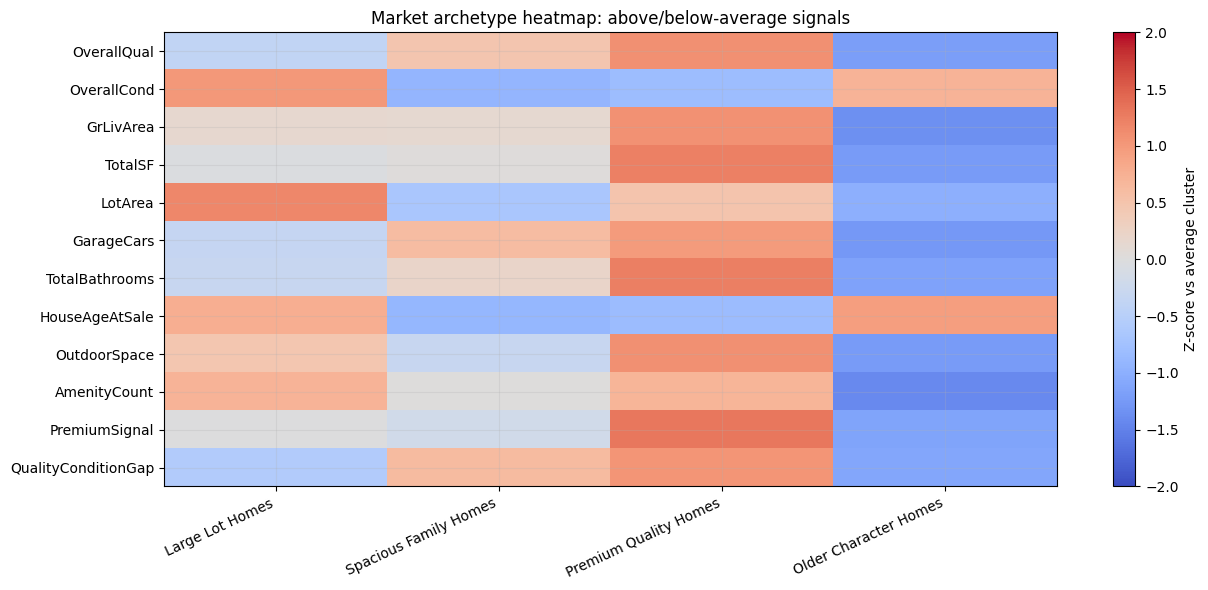

,Archetype,OverallQual,OverallCond,GrLivArea,TotalSF,LotArea,TotalBsmtSF,GarageCars,GarageArea,Fireplaces,TotalBathrooms,HouseAgeAtSale,RemodelAgeAtSale,OutdoorSpace,AmenityCount,PremiumSignal,QualityConditionGap,LotAreaPerRoom,SFPerBedroom
Cluster,,,,,,,,,,,,,,,,,,,
0,Large Lot Homes,5.90,5.96,1623.43,2659.40,13340.19,1045.40,1.71,456.45,1.23,2.15,52.85,32.58,226.61,3.87,1.51,-0.06,2000.54,541.26
1,Spacious Family Homes,6.91,5.08,1619.19,2691.19,9291.39,1072.84,2.19,561.09,0.45,2.45,6.25,5.09,175.37,3.41,1.31,1.83,1378.89,575.87
2,Premium Quality Homes,7.62,5.13,1905.73,3363.28,11849.39,1457.55,2.38,641.10,1.02,3.04,8.56,7.32,268.50,3.86,3.04,2.49,1659.34,736.72
3,Older Character Homes,4.95,5.83,1170.63,1994.79,8572.41,833.60,1.24,342.59,0.07,1.66,57.74,34.95,113.63,2.49,0.19,-0.89,1534.89,434.38


In [ ]:
def assign_cluster_archetypes(profile):
    profile = profile.copy()
    names = {}
    available = set(profile.index)

    if "PremiumSignal" in profile.columns and available:
        c = profile.loc[list(available), "PremiumSignal"].idxmax()
        names[c] = "Premium Quality Homes"
        available.remove(c)

    if "HouseAgeAtSale" in profile.columns and available:
        c = profile.loc[list(available), "HouseAgeAtSale"].idxmax()
        names[c] = "Older Character Homes"
        available.remove(c)

    if "LotArea" in profile.columns and available:
        c = profile.loc[list(available), "LotArea"].idxmax()
        names[c] = "Large Lot Homes"
        available.remove(c)

    if "TotalSF" in profile.columns and available:
        c = profile.loc[list(available), "TotalSF"].idxmax()
        names[c] = "Spacious Family Homes"
        available.remove(c)

    fallback = ["Balanced Suburban Homes", "Compact Value Homes", "Mixed Profile Homes"]
    for c, name in zip(sorted(available), fallback):
        names[c] = name

    return names

cluster_names = assign_cluster_archetypes(cluster_profile)

heatmap_cols = [
    c for c in [
        "OverallQual", "OverallCond", "GrLivArea", "TotalSF", "LotArea",
        "GarageCars", "TotalBathrooms", "HouseAgeAtSale", "OutdoorSpace",
        "AmenityCount", "PremiumSignal", "QualityConditionGap"
    ] if c in cluster_profile.columns
]

heatmap_data = cluster_profile[heatmap_cols]
z_profile = (heatmap_data - heatmap_data.mean(axis=0)) / heatmap_data.std(axis=0)
z_profile = z_profile.replace([np.inf, -np.inf], np.nan).fillna(0)

readable_labels = [cluster_names.get(c, f"Cluster {c}") for c in z_profile.index]

plt.figure(figsize=(13, 6))
plt.imshow(z_profile.T, aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
plt.yticks(range(len(heatmap_cols)), heatmap_cols)
plt.xticks(range(len(z_profile.index)), readable_labels, rotation=25, ha="right")
plt.title("Market archetype heatmap: above/below-average signals")
plt.colorbar(label="Z-score vs average cluster")
plt.tight_layout()
plt.show()

archetype_summary = cluster_profile.copy()
archetype_summary.insert(0, "Archetype", [cluster_names.get(c, f"Cluster {c}") for c in archetype_summary.index])
display(archetype_summary)

### Reading the heatmap

The heatmap uses z-score scaling.

This avoids the misleading “one yellow cluster wins everything” effect. Positive values are above the average cluster profile; negative values are below average.

## 7. Bridge: do archetypes connect with expensive homes?

Now I check how the hidden target behaves inside each discovered cluster.

,Archetype,expensive_rate,n_houses
Cluster,,,
2,Premium Quality Homes,0.527027,296
1,Spacious Family Homes,0.133333,285
0,Large Lot Homes,0.065903,349
3,Older Character Homes,0.000000,530


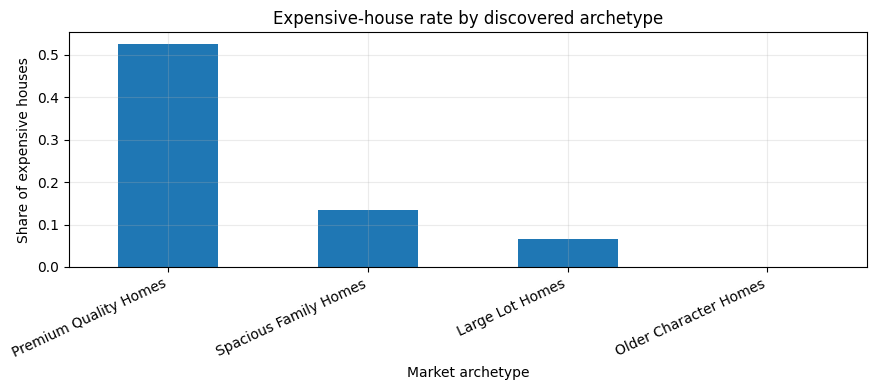

In [ ]:
cluster_target = (
    df_segments
    .groupby("Cluster")[TARGET_COL]
    .agg(["mean", "count"])
    .rename(columns={"mean": "expensive_rate", "count": "n_houses"})
    .sort_values("expensive_rate", ascending=False)
)

cluster_target["Archetype"] = [cluster_names.get(c, f"Cluster {c}") for c in cluster_target.index]

display(cluster_target[["Archetype", "expensive_rate", "n_houses"]])

plot_data = cluster_target.set_index("Archetype")["expensive_rate"]
ax = plot_data.plot(kind="bar", figsize=(9, 4))
ax.set_title("Expensive-house rate by discovered archetype")
ax.set_ylabel("Share of expensive houses")
ax.set_xlabel("Market archetype")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 8. Neighborhood signal

Because this dataset includes `Neighborhood`, I can check whether market archetypes also have location patterns.

In [ ]:
if "Neighborhood" in df_segments.columns:
    neighborhood_by_cluster = (
        df_segments
        .groupby("Cluster")["Neighborhood"]
        .agg(lambda x: x.value_counts().head(3).index.tolist())
        .to_frame("top_neighborhoods")
    )
    neighborhood_by_cluster["Archetype"] = [cluster_names.get(c, f"Cluster {c}") for c in neighborhood_by_cluster.index]
    display(neighborhood_by_cluster[["Archetype", "top_neighborhoods"]])
else:
    print("Neighborhood column not available.")

,Archetype,top_neighborhoods
Cluster,,
0,Large Lot Homes,"[NAmes, NWAmes, Crawfor]"
1,Spacious Family Homes,"[CollgCr, Somerst, Gilbert]"
2,Premium Quality Homes,"[NridgHt, CollgCr, NoRidge]"
3,Older Character Homes,"[NAmes, OldTown, Edwards]"


## 9. Supervised learning

Now I bring the target back and train models to predict whether a house belongs to the expensive segment.

In [ ]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(int)

preprocessor_sup, _, _, _ = build_preprocessor(df, target=TARGET_COL)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=180, min_samples_leaf=3, random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}

baseline_results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor_sup),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    proba_model = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe.named_steps["model"], "predict_proba") else None
    auc = roc_auc_score(y_test, proba_model) if proba_model is not None else np.nan
    baseline_results.append({"model": name, "accuracy": (preds == y_test).mean(), "roc_auc": auc})

baseline_df = pd.DataFrame(baseline_results).sort_values("roc_auc", ascending=False)
display(baseline_df)

,model,accuracy,roc_auc
1,Random Forest,0.958904,0.987298
0,Logistic Regression,0.955479,0.984870
2,Gradient Boosting,0.952055,0.983936


## 10. Final model evaluation

I use a compact Random Forest as the final model because it is stable, interpretable enough for feature importance, and works well on mixed tabular housing data.

Test ROC-AUC: 0.9875

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       249
           1       0.86      0.84      0.85        43

    accuracy                           0.96       292
   macro avg       0.91      0.91      0.91       292
weighted avg       0.96      0.96      0.96       292



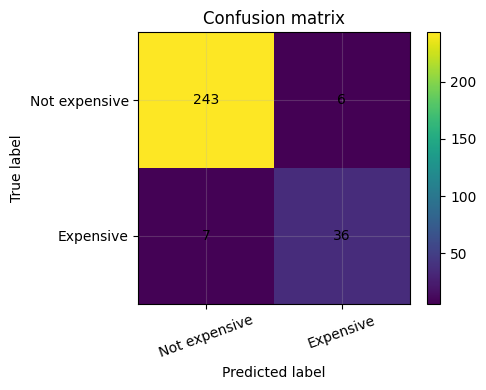

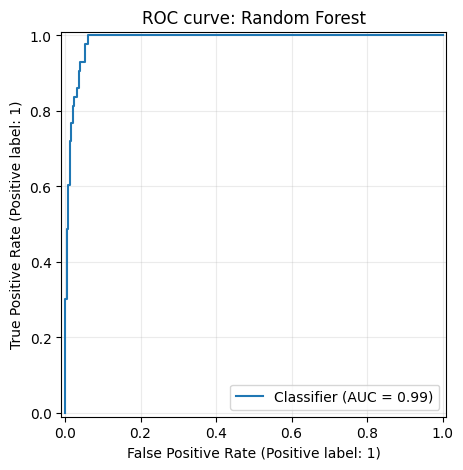

In [ ]:
best_model = Pipeline([
    ("preprocess", preprocessor_sup),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ))
])

best_model.fit(X_train, y_train)

preds = best_model.predict(X_test)
proba = best_model.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", round(roc_auc_score(y_test, proba), 4))
print()
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0, 1], ["Not expensive", "Expensive"], rotation=20)
plt.yticks([0, 1], ["Not expensive", "Expensive"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, proba)
plt.title("ROC curve: Random Forest")
plt.show()

## 11. Threshold analysis

The default 0.50 threshold is not always the best business decision. I inspect precision and recall for different thresholds.

,threshold,precision_expensive,recall_expensive,false_positives,false_negatives
0,0.20,0.623188,1.000000,26,0
1,0.25,0.682540,1.000000,20,0
2,0.30,0.741379,1.000000,15,0
3,0.35,0.759259,0.953488,13,2
4,0.40,0.800000,0.930233,10,3
5,0.45,0.808511,0.883721,9,5
6,0.50,0.857143,0.837209,6,7
7,0.55,0.875000,0.813953,5,8
8,0.60,0.891892,0.767442,4,10
9,0.65,0.911765,0.720930,3,12


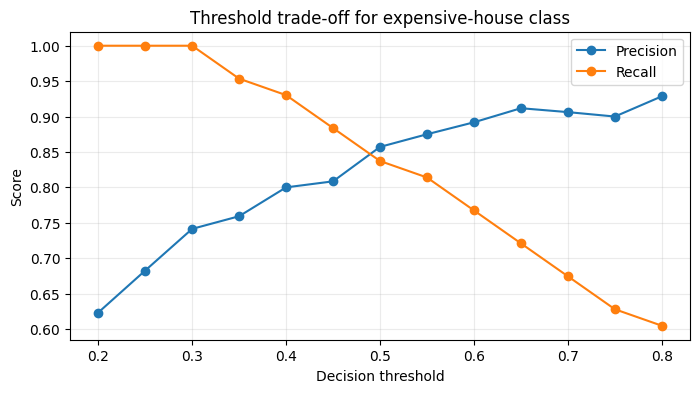

In [ ]:
thresholds = np.arange(0.2, 0.81, 0.05)
rows = []

for threshold in thresholds:
    threshold_preds = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, threshold_preds).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    rows.append({
        "threshold": round(float(threshold), 2),
        "precision_expensive": precision,
        "recall_expensive": recall,
        "false_positives": fp,
        "false_negatives": fn
    })

threshold_df = pd.DataFrame(rows)
display(threshold_df)

plt.figure(figsize=(8, 4))
plt.plot(threshold_df["threshold"], threshold_df["precision_expensive"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall_expensive"], marker="o", label="Recall")
plt.title("Threshold trade-off for expensive-house class")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

## 12. Feature importance

Some top features may be engineered columns such as `TotalSF` or `PremiumSignal`. That is expected: these summarize meaningful market signals.

,feature,importance
36,num__TotalSF,0.112741
52,num__PremiumSignal,0.080778
21,num__GrLivArea,0.069619
10,num__OverallQual,0.058440
51,num__SFPerBedroom,0.048325
2,num__TotalBsmtSF,0.044746
48,num__QualityConditionGap,0.041413
53,ord__ExterQual,0.034588
58,ord__KitchenQual,0.032270
29,num__GarageArea,0.032266


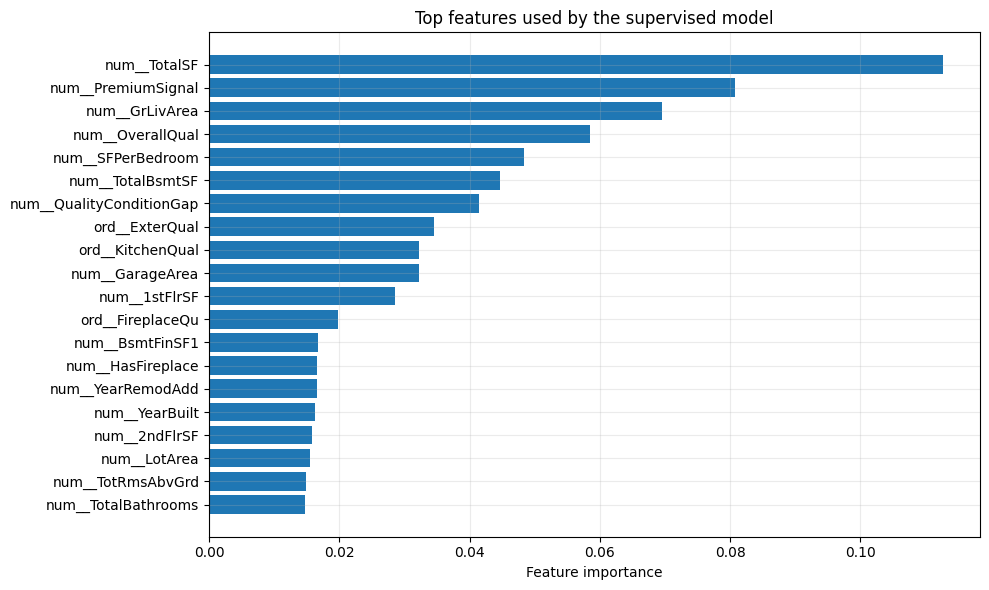

In [ ]:
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
importances = best_model.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
)

display(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1])
plt.title("Top features used by the supervised model")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()

## Research notes

The value of this notebook is the combined perspective:

- unsupervised learning discovers market archetypes without seeing the label,
- the bridge section checks whether expensive homes concentrate in those archetypes,
- supervised learning predicts the target and shows which market signals matter.

This turns the project from a standard classifier into a small housing-market intelligence investigation.

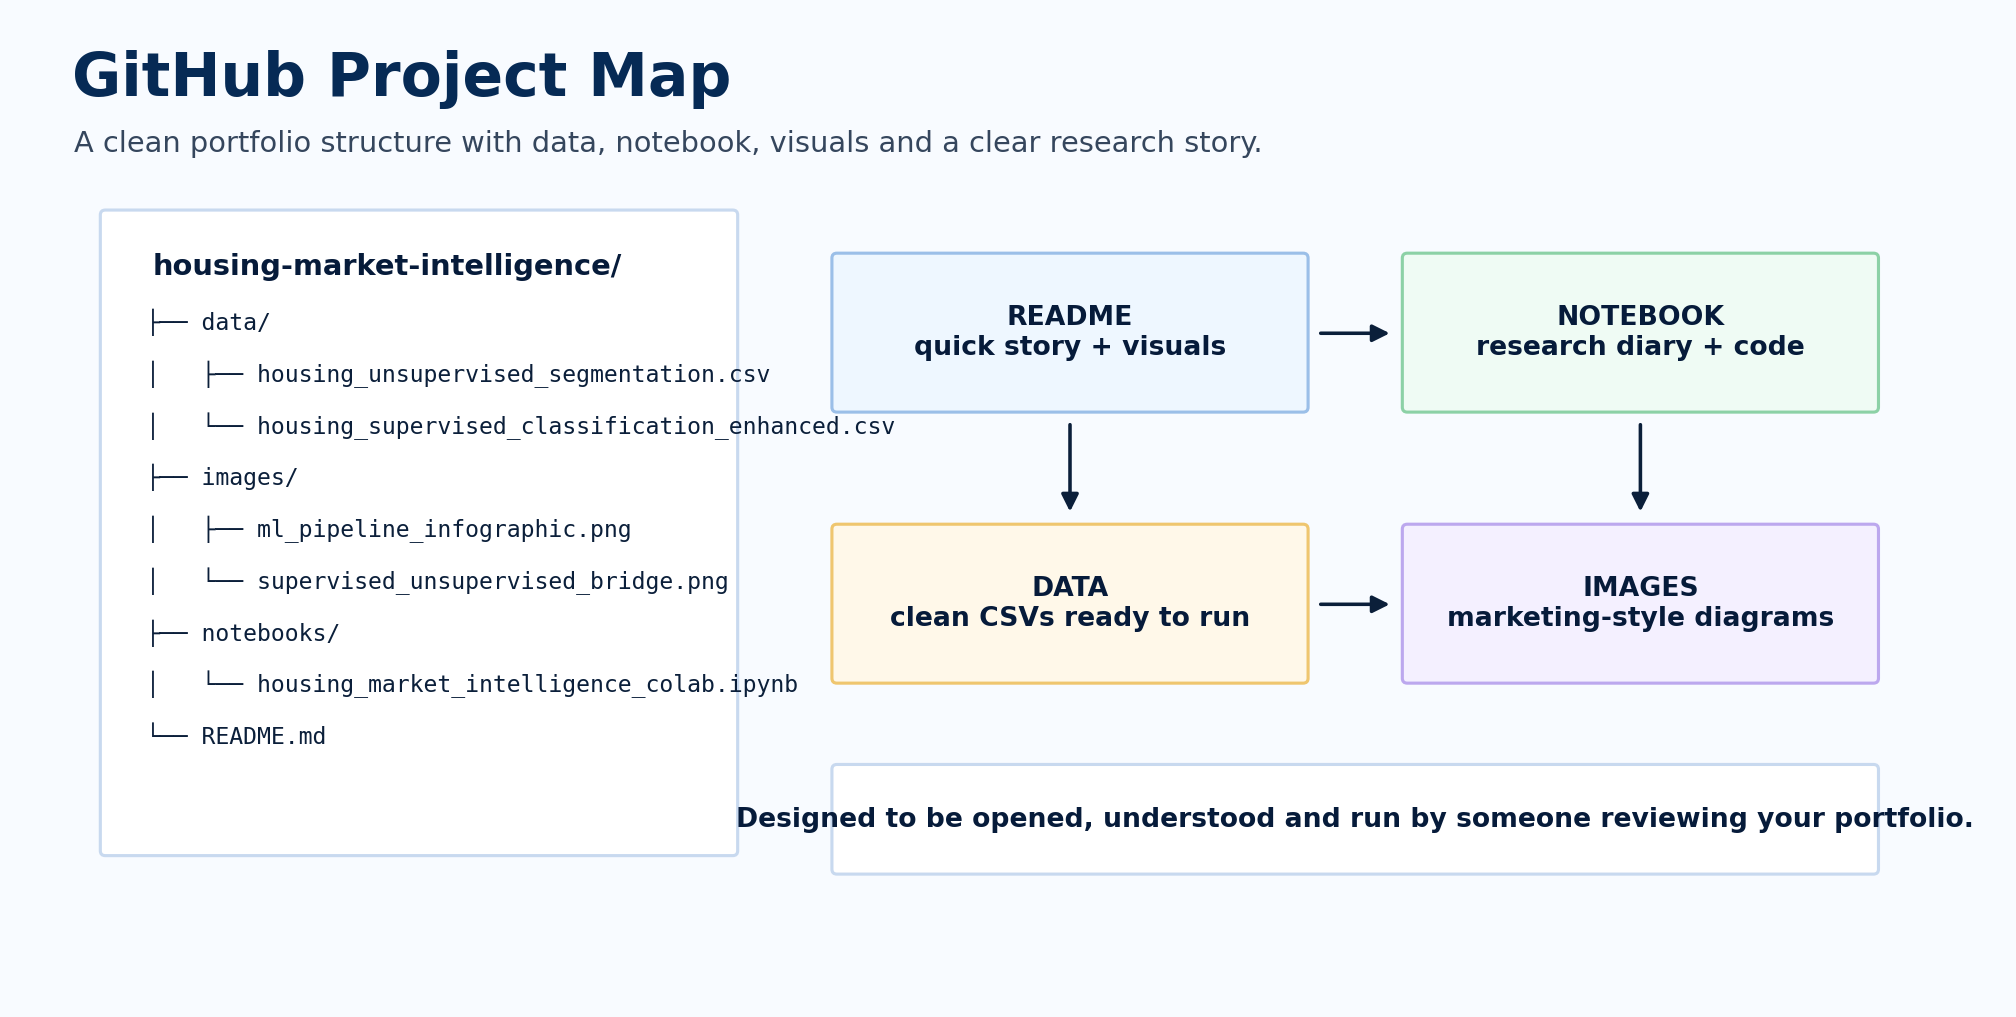

In [23]:
from IPython.display import Image, display

display(Image("/content/drive/MyDrive/Colab Notebooks/images/github_project_map.png"))